<img src="./logo_UTN.svg" align="right" width="150" /> 

# Teoría de Circuitos II

## TP LAB

Autor:
*Facundo Nahuel Sussini*

Integrantes del grupo :
*Juan Pablo Maurin* - *Diego Nicolás Gonzalez* 

Curso: 
*R4052*

Docentes: 
*Mariano Llamedo Soria* - *David Santiago Moharos*    

# Análisis

## Cálculo del Filtro

El filtro pedido, es un Pasa-Altos de las siguientes caracteristicas:

- $F_s = 1.2 KHz$
- $F_c = 4.6 KHz$
- $\alpha_{max} = 1 dB$
- $\alpha_{min} = 20 dB$

Como los cálculos del filtro, se realizaran con un filtro Pasa-Bajos, se harán los siguientes pasos:
- normalizar las frecuencias ($norma_\omega = 4.6KHz$)
- Se invertiran ($1/f$) de tal forma de obtener sus correspondientes frecuencias en Pasa-Bajos (esto ya que la transformación es $ S =\frac{1}{S}$ )


Lo que tendremos en el Pasa-Bajos es:
- $F_s = \frac{1}{\frac{1.2K}{4.6K}} = 3.833$
- $F_c = 1$

La ecuación genérica de un filtro Chebyshev, es la siguiente:

$T(s) = \frac{1}{1+ \epsilon^2 C^2(\omega)}$

Por lo que, para $\omega = 1$, tendríamos la siguiente ecuación:

$$10^{\alpha_{max}/10} = 1+ \epsilon^2$$
$$10^{1/10} = 1+ \epsilon^2$$
$$\epsilon^2 = 0.2589$$
Con el valor de epsilon, despejamos el coeficiente n de la función:

$$10^{\alpha_{min}/10} = 1+ \epsilon^2 \cosh^{2}(n\cosh^{-1}(\omega_s))$$
Iterando el valor de $n$, concluimos que para $n = 2$ se cumple la condición del $\alpha_{min} = 20 dB$

## Cálculo del polinomio de Chebyshev

Para $n = 2$, definimos $C(\omega)$ de la siguiente forma:
$$C(\omega) = 2\omega^2 - 1$$

## Función Transferencia

De esta forma, el módulo de la función transferencia al cuadrado se define como:

$$|T(\omega)|^2 = \frac{1}{1+ \epsilon^2 (2\omega^2 - 1)^2}$$
$$|T(\omega)|^2 = \frac{1}{1+ \epsilon^2 (4\omega^2 - 4\omega^2 + 1)}$$
$$|T(\omega)|^2 = \frac{\frac{1}{4\epsilon^2 }}{\omega^4 - \omega^2 + 1/4 + \frac{1}{4\epsilon^2 }}$$
$$|T(\omega)|^2 = |T(S/j)|^2 = |T(S)|^2 = \frac{\frac{1}{4\epsilon^2 }}{S^4  + S^2 + 1/4 + \frac{1}{4\epsilon^2 }}$$

Una función genérica de segundo órden (multiplicada por su conjugado) dá de la siguiente manera:
$$|T(S)|^2 = \frac{c}{s^2+ S a + b} \frac{c}{s^2 - S a + b}$$

Si se realiza la distributiva, y se comparan los valores con los obtenidos en la transferencia del Pasa-Bajos, se obtiene que:
$$C = \frac{1}{2\epsilon} = 0.982$$
$$b = \sqrt{1/4+\frac{1}{4\epsilon^2}} = 1.102$$
$$a = \sqrt{2b - 1} = \sqrt{2*1.102 - 1} = 1.0977$$

Teniendo estos coeficientes, la transferencia final queda de la siguiente forma:
$$T(S) = \frac{c}{s^2+ S a + b} = \frac{0.982}{s^2+ S 1.0977 + 1.102}$$


## Función Transferencia Pasa-Altos

Como se analizó, para transformar un circuito Pasa-Bajos en un Pasa-Altos, se toma que $S = \frac{1}{S}$

$$T_{LP}(S) = \frac{c}{s^2+ S a + b} = \frac{0.982}{s^2+ S 1.0977 + 1.102}$$
$$T_{HP}(S) = \frac{s^2 0.982}{1+ S 1.0977 + s^2 1.102}$$
$$T_{HP}(S) = \frac{s^2 \frac{0.982}{1.102}}{s^2 + S \frac{1.0977}{1.102} + \frac{1}{1.102}}$$

Ahora, se desnormaliza en frecuencia: $S = S \frac{1}{2\pi4.6KHz} = S \frac{1}{28.9KHz}$

$$T_{HP}(S) = \frac{s^2 \frac{0.982}{1.102}}{s^2 + S \frac{1.0977 * 28.9KHz}{1.102} + \frac{(28.9KHz)^2}{1.102}}$$

Finalmente, la transferencia final, queda de la siguiente manera:

$$T_{HP}(S) = \frac{s^2 0.891}{s^2 + S 28.78K+ 758M}$$


## Parte de la datasheet UAF42 para el calculo de los Valores de Componentes

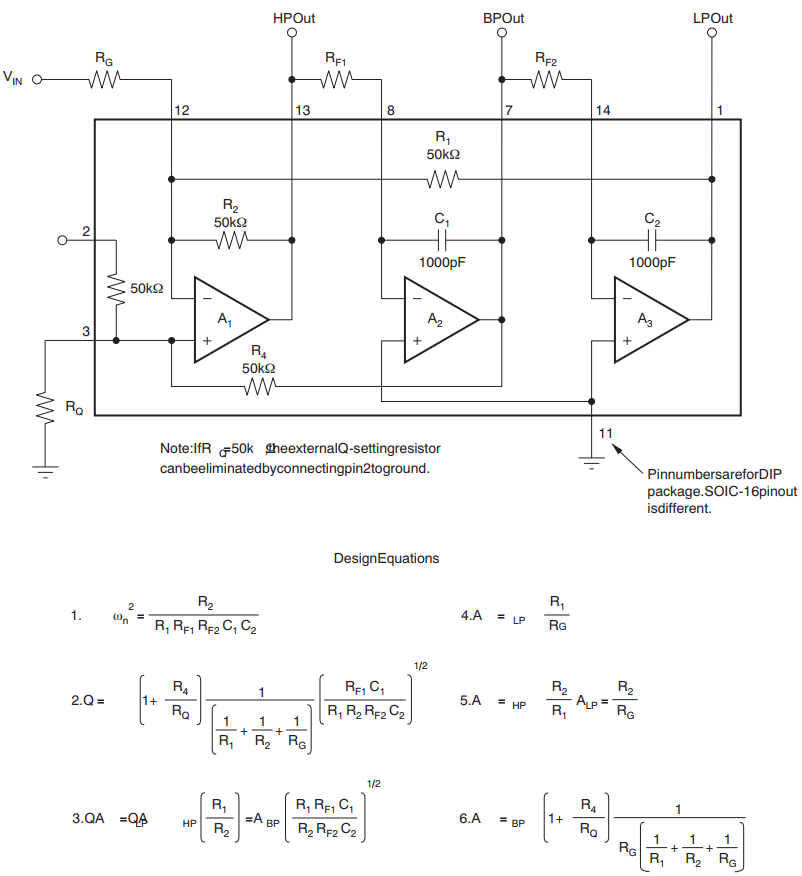

## Cálculo de Valores de Componentes

De la transferencia obtenemos:

$$\omega_0^2 = \frac{R_2}{R_1 R_{F1} R_{F2} C_1 C_2} = 758.10^6$$
$$Q = \frac{1 + \frac{R_4.(R_G + R_Q)}{R_G.R_Q}}{1 + \frac{R_2}{R_1}}.(\frac{R_2 R_{F1} C_1}{R_1 R_{F2} C2})^\frac{1}{2}$$
$$A_{HP} = \frac{1 + \frac{R_2}{R_1}}{R_G.(\frac{1}{R_G}.\frac{1}{R_Q}.\frac{1}{R_4})} = 0.891$$
$$\frac{\omega_0}{Q} = 28.78.10^3 $$

Entonces:

$$\omega_0 = 27531.8\frac{rad}{seg}$$
$$Q = 0.9566$$

Con $R_1 = R_2 = R_4 = 50K\Omega$,  y  $C_1 = C_2 = 1000pF$, y asumiendo $R_G = R_Q$ entonces: 

$$0.891 = \frac{2}{R_G.(\frac{1}{R_G}.\frac{1}{R_Q}.\frac{1}{50K})}$$
$$R_G = R_Q = 12233.44\Omega$$
$$R_G = R_Q = 12K\Omega$$

Luego, para obtener $R_F1$ y $R_F2$:

$$758M = \frac{50K\Omega}{50K\Omega R_{F1} R_{F2} 1000pF 1000pF}$$
$$R_{F1} R_{F2} = 1.3192.10^9$$
$$R_{F1} = \frac{1.3192.10^9}{R_{F2}}$$

$$0.9566 = \frac{14}{3} . \sqrt{\frac{1.3192.10^9}{R_{F2}}}$$
$$R_{F2} = 177.186K\Omega = 180K\Omega$$
$$R_{F1} = 7328\Omega = 6K8\Omega$$

Optamos por poner $R_{F1} = 6K8\Omega$ y poner un preset de $5K\ohm$ en serie para poder regular la resistencia hasta obtener el $\alpha_{max}$ pedido

# Simulaciones

## Simulación numérica en Python

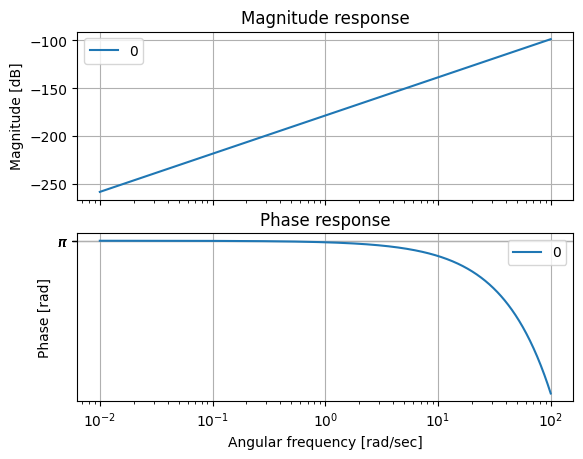

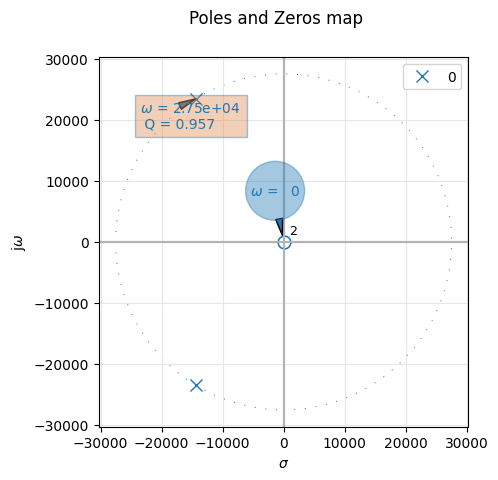

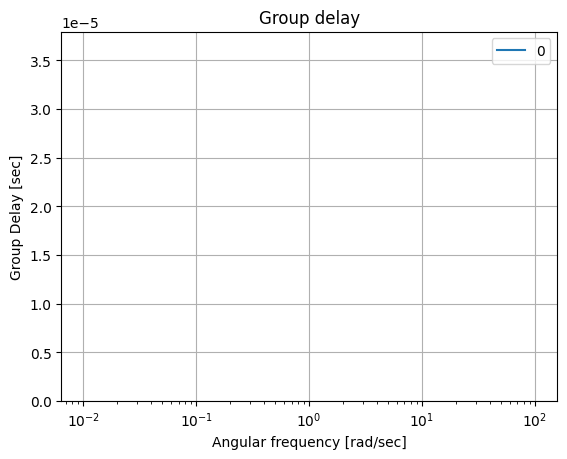

In [19]:
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq

from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys


my_tf = TransferFunction( [0.891,0,0], [1,28.78e3,758e6] )

#bodePlot(my_tf, fig_id=1)

#pzmap(my_tf, fig_id=2) #S plane pole/zero plot

analyze_sys(my_tf)

Como se pudo observar se cumplio con la plantilla dada

## Simulación circuital en LtSpice

- Circuito en LtSpice:

<img src="./Circuito_Spice.png" align="center" width="800" /> 

- Simulación de Módulo y Fase:

<img src="./moduloYfase.png" align="center" width="800" /> 

Se puede observar que la fase pasa de 180° a 0° , tanto en las simulaciones y en la practica. Se puede interpretar -180° como 180° , porque son escencialmente lo mismo (es relevante en la practica)

- Valor del cursor en la "Simulacion de Modulo y Fase"

 <img src="./valorDeCursores.png" align="center" width="800" />  
 Se puede observar que a una frecuencia de aproximadamente 1.2KHz se tiene una atenuacion de mas de 20dB . Y que en 4.6Khz se tiene un aproximado de 1dB.

- Simulación de Retardo de Grupo (es la linea punteada):

<img src="./Simulacion_Modulo-DelayDeGrupo.png" align="center" width="800" /> 

# Armado de la Placa

- Esquemático de la placa:

<img src="./Circuito_Esquematico.png" align="center" width="800" /> 

- PCB Layout:

<img src="./Circuito_ImpresoPCB.png" align="center" width="700" /> 

- Módelo de simulación 3D:

<img src="./Circuito_Modelo3D.png" align="center" width="700" /> 

# Laboratorio

## Instrumental

El instrumental requerido en la práctica fue el siguiente:
- Dos fuentes de tensión V&A modelo HY3005D (números de identificación NG1818 y NG1816).
- Osciloscopio Gw Instek modelo GDS-1102A-U (número de identificación NG1841).
- Generador de señales Twintex modelo TFG-3205E (número de identificación NG1897).
- 2 pares de cables cocodrilo-cocodrilo.
- 2 cables de medición del osciloscopio (para la entrada y la salida).
- Cable para el generador de señales.
- Tester

## Montaje

Montaje y conexiones de la placa:

<img src="./montaje.jpeg" align="center" width="700" /> 

<img src="./montaje2.jpeg" align="center" width="700" /> 

## Mediciones

Las mediciones fueron realizadas para tensiones de fuentes iguales a $8V$, con una limitación de corriente de $40mA$ en cada fuente, y el generador de señales configurado para una señal senoidal de amplitud $4V_{pp}$ y frecuencia variable.

Realizamos una totalidad de 22 mediciones a varias frecuencias y fuimos midiendo la amplitud de la señal de salida en comparación a la de entrada, y la demora de fase.

## Imagenes de Importancia

Frecuencia mínima de trabajo = $600Hz$(justo encima del piso de ruido):

<img src="./freqmin.jpeg" align="center" width="700" /> 

Frecuencia de corte inferior = $1.2KHz$:

<img src="./fci.jpeg" align="center" width="700" /> 

Frecuencia de corte superior = $4.6KHz$:

<img src="./fcs.jpeg" align="center" width="700" /> 

Frecuencia de 0dB de ganancia = $6.5KHz$:

<img src="./0db.jpeg" align="center" width="700" /> 

Frecuencia donde hay una deformacion en la señal = $4KHz$:

<img src="./peculiaridad.jpeg" align="center" width="700" /> 

Imágen de la transferencia medida con 30 puntos:

<img src="./Grupo_2_HPF_Modulo.jpeg" align="center" width="700" /> 

Imágen de la fase medida con 30 puntos (los picos son los mismos que siguen la gráfica pero con un cambio de $2\pi$):

<img src="./Grupo_2_HPF_Fase.jpeg" align="center" width="700" /> 

# Valores Medidos
A continuacion, se utilizara phyton pára representar las curvas de modulo, fase, y retraso de grupo, en base a las mediciones tomadas

In [20]:
import numpy as np

data_in = 1  # Saltear la fila con "4Vpp" si querés

# Leer columnas: Freq a medir, Modulo, Retardo
data_ch1 = np.genfromtxt(
    './Medidas.csv',
    delimiter=';',
    dtype='U20',
    skip_header=1,
    usecols=(1, 2, 3),  # Freq a medir, Modulo, Retardo
    encoding='utf-8'
)

freq_raw = data_ch1[data_in:, 0]
amp_raw = data_ch1[data_in:, 1]
ret_raw = data_ch1[data_in:, 2]


# Función para convertir "0,6K" → 600.0
def parse_freq(f):
    if not f:
        return np.nan
    f = f.replace(',', '.').upper().strip()
    if f.endswith('K'):
        return float(f[:-1]) * 1000
    elif f.endswith('M'):
        return float(f[:-1]) * 1_000_000
    else:
        return float(f)

# Función para convertir "3,83Vpp" → 3.83
def parse_amp(a):
    if not a:
        return np.nan
    a = a.replace(',', '.').upper().strip()
    if 'MVPP' in a:
        return float(a.replace('MVPP', '')) * 1e-3
    elif 'VPP' in a:
        return float(a.replace('VPP', ''))
    else:
        return float(a)

# Función para convertir "740us", "120ns", etc. → segundos (float)
def parse_ret(r):
    if not r:
        return np.nan
    r = r.replace(',', '.').lower().strip()
    if r.endswith('ns'):
        return float(r.replace('ns', '')) * 1e-9
    elif r.endswith('us'):
        return float(r.replace('us', '')) * 1e-6
    elif r.endswith('ms'):
        return float(r.replace('ms', '')) * 1e-3
    elif r.endswith('s'):
        return float(r.replace('s', ''))
    else:
        return float(r)  # por si viene limpio

# Aplicar funciones
freq = np.array([parse_freq(f) for f in freq_raw])
amplitud = np.array([parse_amp(a) for a in amp_raw])
retardo = np.array([parse_ret(r) for r in ret_raw])

# Imprimir para verificar
print("FRECUENCIAS:", freq)
print("AMPLITUDES:", amplitud)
print("RETARDOS (en segundos):", retardo)


FRECUENCIAS: [   900.   1200.   2000.   3000.   4000.   4600.   4800.   5000.   5200.
   5600.   6000.   6500.   7000.   7500.   8000.   8500.  10000.  15000.
  20000.  50000. 100000.]
AMPLITUDES: [0.182 0.315 0.944 2.27  3.24  3.61  3.68  3.75  3.83  3.92  4.    4.03
 4.07  4.    3.96  3.96  3.83  3.68  3.6   3.51  3.51 ]
RETARDOS (en segundos): [5.20e-04 3.68e-04 2.02e-04 1.08e-04 5.40e-05 4.00e-05 3.40e-05 3.20e-05
 3.20e-05 2.60e-05 2.20e-05 1.80e-05 1.60e-05 1.50e-05 1.20e-05 9.00e-06
 6.40e-06 4.00e-06 1.40e-06 4.00e-07 1.20e-07]


C:\Users\Usuario\AppData\Local\Temp\ipykernel_8640\2711495330.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


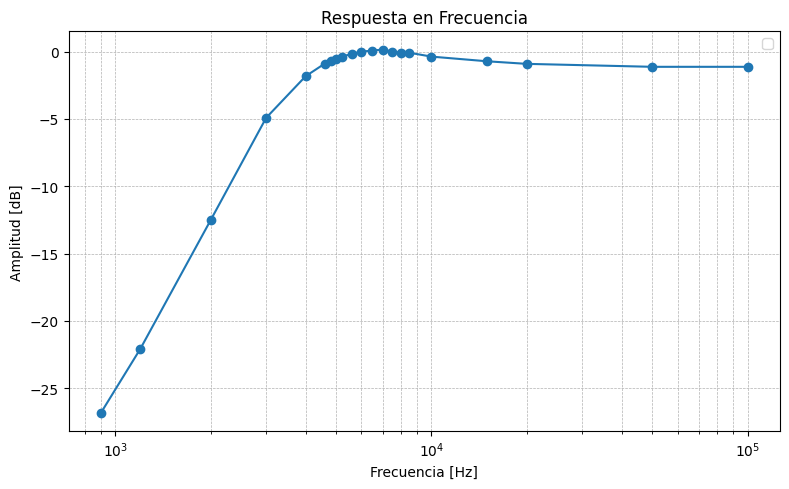

In [21]:
import matplotlib.pyplot as plt

# Calcular amplitud en dB
amplitud_db = 20 * np.log10(amplitud/4)

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.semilogx(freq, amplitud_db, marker='o', linestyle='-', linewidth=1.5)

plt.legend()

# Etiquetas y estilo
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.title('Respuesta en Frecuencia')
plt.tight_layout()
plt.show()


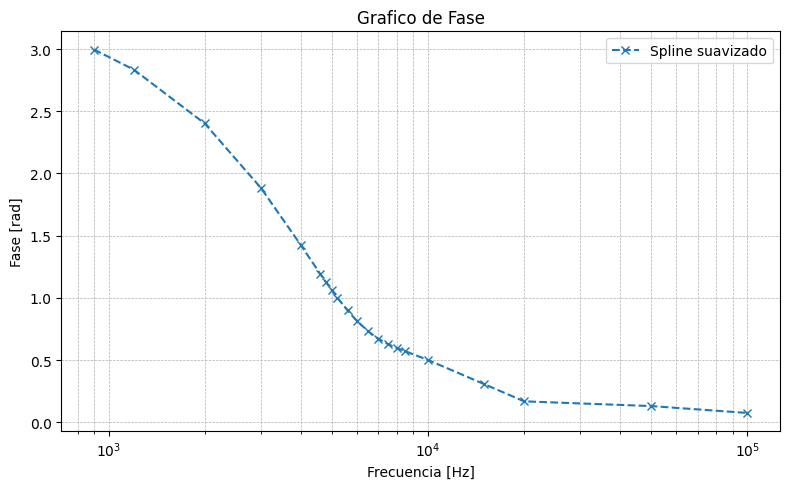

In [22]:
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Calcular fase angular en radianes
fase_rad = 2 * np.pi * freq * retardo

# Crear spline suavizado de la fase (s=0.1 ajusta el nivel de suavizado)
spline_fase = UnivariateSpline(freq, fase_rad, s=0.1)

# Evaluar el spline en los mismos puntos
fase_rad_spline = spline_fase(freq)

# Graficar ambas fases
plt.figure(figsize=(8, 5))
plt.semilogx(freq, fase_rad_spline, marker='x', linestyle='--', linewidth=1.5, label='Spline suavizado')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.title('Grafico de Fase')
plt.legend()
plt.tight_layout()
plt.show()


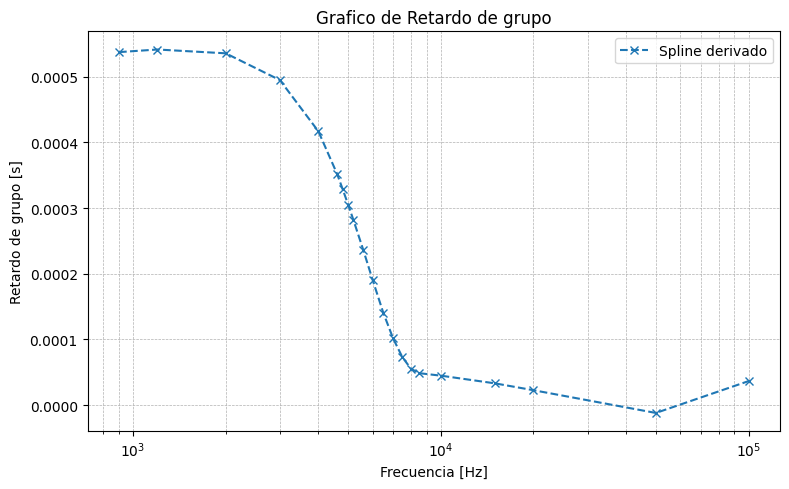

In [23]:
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# --- Método 1: Derivada numérica directa ---
group_delay_gradient = -np.gradient(fase_rad, freq)

# --- Método 2: Interpolación spline + derivada ---
spline_fase = UnivariateSpline(freq, fase_rad, s=0.1)
fase_derivada_spline = spline_fase.derivative()
group_delay_spline = -fase_derivada_spline(freq)

# --- Gráfico comparativo ---
plt.figure(figsize=(8, 5))
#plt.semilogx(freq, group_delay_gradient, marker='o', linestyle='-', linewidth=1.5, label='np.gradient')
plt.semilogx(freq, group_delay_spline, marker='x', linestyle='--', linewidth=1.5, label='Spline derivado')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Retardo de grupo [s]')
plt.title('Grafico de Retardo de grupo')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
magnitud_db = 20 * np.log10(amplitud / 4)
fase_rad = 2 * np.pi * freq * retardo  # o el +2π que vos le sumaste

print(f"{'Frecuencia [Hz]':>15} | {'Magnitud [dB]':>15} | {'Fase [rad]':>15}")
print("-" * 50)

# Filas
for f, m, ph in zip(freq, magnitud_db, fase_rad):
    print(f"{f:15.2f} | {m:15.2f} | {ph:15.4f}")


Frecuencia [Hz] |   Magnitud [dB] |      Fase [rad]
--------------------------------------------------
         900.00 |          -26.84 |          2.9405
        1200.00 |          -22.07 |          2.7747
        2000.00 |          -12.54 |          2.5384
        3000.00 |           -4.92 |          2.0358
        4000.00 |           -1.83 |          1.3572
        4600.00 |           -0.89 |          1.1561
        4800.00 |           -0.72 |          1.0254
        5000.00 |           -0.56 |          1.0053
        5200.00 |           -0.38 |          1.0455
        5600.00 |           -0.18 |          0.9148
        6000.00 |            0.00 |          0.8294
        6500.00 |            0.06 |          0.7351
        7000.00 |            0.15 |          0.7037
        7500.00 |            0.00 |          0.7069
        8000.00 |           -0.09 |          0.6032
        8500.00 |           -0.09 |          0.4807
       10000.00 |           -0.38 |          0.4021
       15000.

# Conclusión

Se pudo llegar a la conclusion que los calculos , simulaciones y practica de laboratorio , todos dieron resultados de comportaminetos aceptablemente parecidos . Las fases , magnitudes y retardo de grupo corresponden muy bien a lo pedido en la consigna original. Idealmente se tendria que haber llegado a una atenuacion de -1dB cuando llego a la banda de paso, pero solo obtuvimos entre -1.8 a -1.6 dB , muy seguramente a variaciones normales de los componentes usados.   